In [1]:
%pip install pandas matplotlib
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

Note: you may need to restart the kernel to use updated packages.


In [2]:

# Loading our attrition data into a pandas dataframe
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

In [3]:
# Attrition rate by each useful column
# AttritionRate is the share of employees in each group who left.

# Make a new column AttritionFlag that is True (1) for employees who left and False (0) for those who stayed.
df["AttritionFlag"] = df["Attrition"].eq("Yes")

# Compute the overall attrition rate to use as a baseline for comparison.
baseline_rate = df["AttritionFlag"].mean()
print(f"Overall attrition rate: {baseline_rate:.1%}")

# Identify columns that are not useful for attrition analysis.
constant_columns = [
    column for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]
identifier_columns = ["EmployeeNumber"]
exclude_columns = {"Attrition", "AttritionFlag", *constant_columns, *identifier_columns}

# Group attrition rates by each useful column, and compare to the overall baseline rate.
results = []
for column in df.columns:
    # Skip columns that are not useful for attrition analysis.
    if column in exclude_columns:
        continue
    grouped_data = df[[column, "AttritionFlag"]].copy()
    group_column = column
    # If the column is numeric, create quartile bands to group the data.
    if pd.api.types.is_numeric_dtype(grouped_data[column]):
        group_column = f"{column}Band"
        grouped_data[group_column] = pd.qcut(
            grouped_data[column],
            q=4,
            duplicates="drop"
        )
    # Compute the attrition rate for each group and compare to the baseline.
    grouped_rates = (
        grouped_data
        .groupby(group_column, observed=False)["AttritionFlag"]
        .agg(
            Employees="size",
            Leavers="sum",
            AttritionRate="mean"
        )
        .reset_index()
    )

    # Add the column name to the results so we can identify which feature each group belongs to.
    grouped_rates.insert(0, "Feature", column)
    grouped_rates["RateVsBaseline"] = grouped_rates["AttritionRate"] - baseline_rate
    results.append(grouped_rates)

attrition_by_group = pd.concat(results, ignore_index=True)

# Sort the largest groups first so small, unstable groups do not dominate the view.
attrition_by_group = attrition_by_group.sort_values(
    ["Feature", "Employees"],
    ascending=[True, False]
)

# Pearson correlation with the binary AttritionFlag is a quick numeric screening tool.
numeric_columns = [
    column for column in df.select_dtypes(include="number").columns
    if column not in exclude_columns
]
# Compute the correlation of each numeric column with AttritionFlag, and sort by absolute value.
attrition_correlations = (
    df[numeric_columns]
    .corrwith(df["AttritionFlag"])
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("CorrelationWithAttrition")
    .to_frame()
)

# Keep numeric values for plotting and create a formatted copy for display.
attrition_by_group_display = attrition_by_group.copy()
attrition_by_group_display["AttritionRate"] = attrition_by_group_display["AttritionRate"].map(
    lambda rate: f"{rate:.1%}"
)
attrition_by_group_display["RateVsBaseline"] = attrition_by_group_display["RateVsBaseline"].map(
    lambda rate: f"{rate:+.1%}"
)

print("\nGrouped attrition rates:")
display(attrition_by_group_display.head(30))
print("\nNumeric correlations with AttritionFlag:")
display(attrition_correlations)

Overall attrition rate: 16.1%

Grouped attrition rates:


,Feature,AgeBand,Employees,Leavers,AttritionRate,RateVsBaseline,BusinessTravel,DailyRateBand,Department,DistanceFromHomeBand,...,PerformanceRatingBand,RelationshipSatisfactionBand,StockOptionLevelBand,TotalWorkingYearsBand,TrainingTimesLastYearBand,WorkLifeBalanceBand,YearsAtCompanyBand,YearsInCurrentRoleBand,YearsSinceLastPromotionBand,YearsWithCurrManagerBand
1,Age,"(30.0, 36.0]",412,66,16.0%,-0.1%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Age,"(17.999, 30.0]",386,100,25.9%,+9.8%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age,"(43.0, 60.0]",347,42,12.1%,-4.0%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Age,"(36.0, 43.0]",325,29,8.9%,-7.2%,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,BusinessTravel,NaN,1043,156,15.0%,-1.2%,Travel_Rarely,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,BusinessTravel,NaN,277,69,24.9%,+8.8%,Travel_Frequently,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BusinessTravel,NaN,150,12,8.0%,-8.1%,Non-Travel,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,DailyRate,NaN,369,74,20.1%,+3.9%,NaN,"(101.999, 465.0]",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,DailyRate,NaN,367,59,16.1%,-0.0%,NaN,"(465.0, 802.0]",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,DailyRate,NaN,367,56,15.3%,-0.9%,NaN,"(802.0, 1157.0]",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Numeric correlations with AttritionFlag:


,CorrelationWithAttrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
JobInvolvement,-0.130016
JobSatisfaction,-0.103481


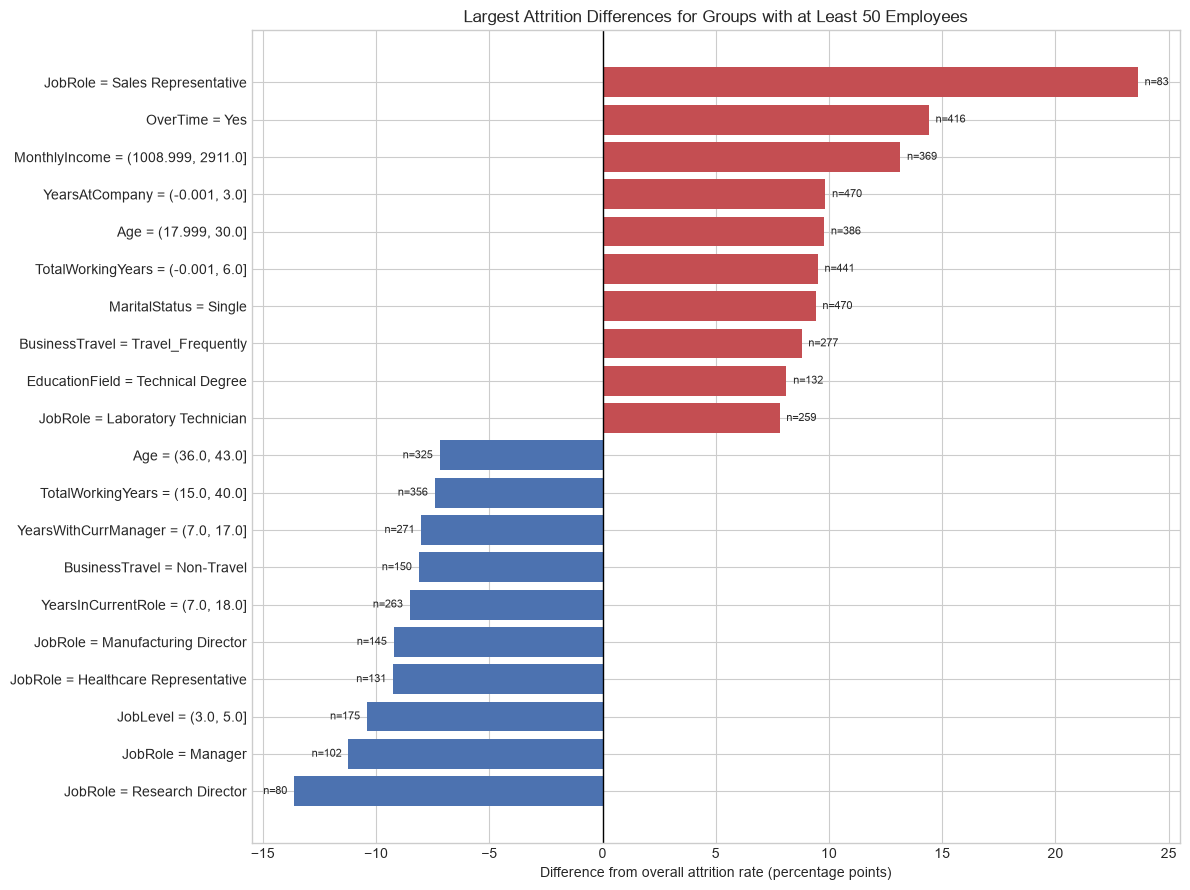

In [10]:
# Graph the groups with the largest differences from the overall attrition rate.
plot_data = attrition_by_group.copy()
value_columns = {"Feature", "Employees", "Leavers", "AttritionRate", "RateVsBaseline"}
plot_data["Group"] = plot_data.apply(
    lambda row: next(
        str(row[column])
        for column in plot_data.columns
        if column not in value_columns and pd.notna(row[column])
    ),
    axis=1
)
plot_data["Label"] = plot_data["Feature"] + " = " + plot_data["Group"]
plot_data = plot_data[plot_data["Employees"] >= 50].assign(
    AbsoluteDifference=lambda data: data["RateVsBaseline"].abs()
).nlargest(20, "AbsoluteDifference").sort_values("RateVsBaseline")

fig, ax = plt.subplots(figsize=(12, 9))
colors = ["#c44e52" if value > 0 else "#4c72b0" for value in plot_data["RateVsBaseline"]]
ax.barh(plot_data["Label"], plot_data["RateVsBaseline"] * 100, color=colors)
ax.axvline(0, color="black", linewidth=1)
for bar, difference, employees in zip(
    ax.patches,
    plot_data["RateVsBaseline"],
    plot_data["Employees"]
):
    offset = 0.3 if difference >= 0 else -0.3
    alignment = "left" if difference >= 0 else "right"
    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f"n={employees}",
        va="center",
        ha=alignment,
        fontsize=8
    )
ax.set_xlabel("Difference from overall attrition rate (percentage points)")
ax.set_title("Largest Attrition Differences for Groups with at Least 50 Employees")
plt.tight_layout()
plt.show()

In [13]:
# The numeric correlations are weak, so they should be treated as screening signals rather than causal explanations.
# The strongest negative relationships are with TotalWorkingYears, JobLevel, YearsInCurrentRole,
# MonthlyIncome, Age, and YearsWithCurrManager. Positive relationships appear for DistanceFromHome,
# NumCompaniesWorked, and MonthlyRate, but they are also weak and do not establish causation.
# The grouped attrition rates provide more interpretable patterns, such as higher attrition among
# employees with fewer years worked, fewer years at the company, lower monthly income, and younger age.
# These patterns should be investigated further with sample sizes and additional statistical analysis.

In [5]:
# Compute the correlation of each numeric column with AttritionFlag, and sort by absolute value.
correlation_data = df[numeric_columns].copy()
correlation_data["AttritionFlag"] = df["AttritionFlag"].astype(int)

correlation_table = (
    correlation_data.corr()["AttritionFlag"]
    .drop("AttritionFlag")
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("CorrelationWithAttrition")
    .to_frame()
)
correlation_table

,CorrelationWithAttrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392
JobInvolvement,-0.130016
JobSatisfaction,-0.103481


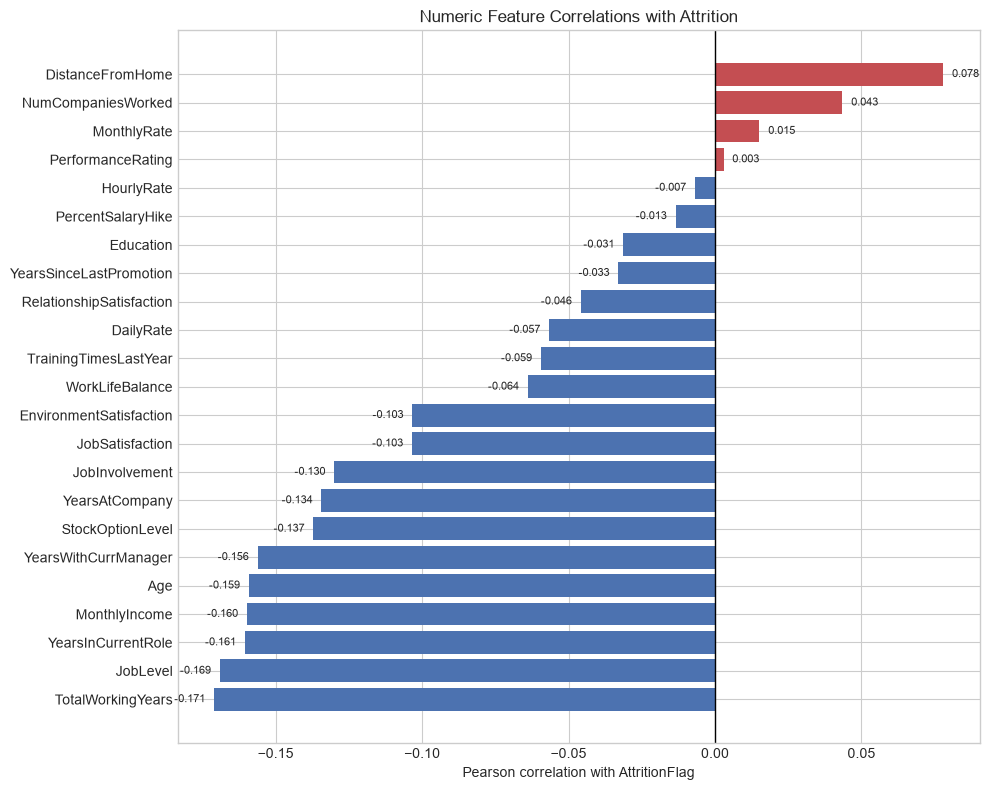

In [11]:
# Graph the numeric correlations with AttritionFlag.
correlation_plot_data = correlation_table.sort_values("CorrelationWithAttrition")
fig, ax = plt.subplots(figsize=(10, 8))
colors = [
    "#c44e52" if value > 0 else "#4c72b0"
    for value in correlation_plot_data["CorrelationWithAttrition"]
]
ax.barh(
    correlation_plot_data.index,
    correlation_plot_data["CorrelationWithAttrition"],
    color=colors
)
ax.axvline(0, color="black", linewidth=1)
for feature, correlation in correlation_plot_data["CorrelationWithAttrition"].items():
    offset = 0.003 if correlation >= 0 else -0.003
    alignment = "left" if correlation >= 0 else "right"
    ax.text(
        correlation + offset,
        feature,
        f"{correlation:.3f}",
        va="center",
        ha=alignment,
        fontsize=8
    )
ax.set_xlabel("Pearson correlation with AttritionFlag")
ax.set_title("Numeric Feature Correlations with Attrition")
plt.tight_layout()
plt.show()

In [7]:
# Create one grouped correlation DataFrame for every analyzed feature.
attrition_correlations_by_group = {}

for feature in attrition_correlations.index:
    # Create a DataFrame with the feature, group, and attrition correlation for each group of the feature.
    feature_data = df[[feature, "AttritionFlag"]].copy()
    # If the feature is numeric, create quartile bands to group the data.
    if pd.api.types.is_numeric_dtype(feature_data[feature]):
        feature_data["Group"] = pd.qcut(
            feature_data[feature],
            q=4,
            duplicates="drop"
        )
    else:
        feature_data["Group"] = feature_data[feature].fillna("Missing")
    # Compute the attrition rate and correlation for each group of the feature.
    group_rows = []
    for group_value, group in feature_data.groupby(
        "Group",
        observed=False,
        sort=False
    ):
        #   Compute the correlation of the group membership with AttritionFlag.
        group_membership = feature_data["Group"].eq(group_value).astype(int)
        group_rows.append({
            "Feature": feature,
            "Group": group_value,
            "Employees": len(group),
            "Leavers": int(group["AttritionFlag"].sum()),
            "AttritionRate": group["AttritionFlag"].mean(),
            "RateVsBaseline": group["AttritionFlag"].mean() - baseline_rate,
            "GroupAttritionCorrelation": group_membership.corr(
                feature_data["AttritionFlag"].astype(int)
            ),
        })
    # Store the grouped correlation DataFrame in a dictionary for later use.
    attrition_correlations_by_group[feature] = pd.DataFrame(group_rows)

c:\Users\11yun\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\11yun\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [8]:
# Display the grouped correlation DataFrames for each feature, sorted by group.
for feature, correlation_df in attrition_correlations_by_group.items():
    print(f"\n{feature}")
    # Sort the correlation DataFrame by group for easier reading.
    sorted_correlation_df = correlation_df.sort_values(
        "Group",
        ascending=True
    ).reset_index(drop=True).copy()
    # Format the attrition rates as percentages for easier reading.
    sorted_correlation_df["AttritionRate"] = sorted_correlation_df[
        "AttritionRate"
    ].map(lambda rate: f"{rate:.1%}")
    # Format the difference from baseline as a percentage with a sign to indicate whether the group is above or below the baseline.
    sorted_correlation_df["RateVsBaseline"] = sorted_correlation_df[
        "RateVsBaseline"
    ].map(lambda rate: f"{rate:+.1%}")
    
    display(sorted_correlation_df)


TotalWorkingYears


,Feature,Group,Employees,Leavers,AttritionRate,RateVsBaseline,GroupAttritionCorrelation
0,TotalWorkingYears,"(-0.001, 6.0]",441,113,25.6%,+9.5%,0.169141
1,TotalWorkingYears,"(6.0, 10.0]",482,69,14.3%,-1.8%,-0.034323
2,TotalWorkingYears,"(10.0, 15.0]",191,24,12.6%,-3.6%,-0.037379
3,TotalWorkingYears,"(15.0, 40.0]",356,31,8.7%,-7.4%,-0.113981



JobLevel


,Feature,Group,Employees,Leavers,AttritionRate,RateVsBaseline,GroupAttritionCorrelation
0,JobLevel,"(0.999, 2.0]",1077,195,18.1%,+2.0%,0.089286
1,JobLevel,"(2.0, 3.0]",218,32,14.7%,-1.4%,-0.016380
2,JobLevel,"(3.0, 5.0]",175,10,5.7%,-10.4%,-0.104045



YearsInCurrentRole


...

,Feature,Group,Employees,Leavers,AttritionRate,RateVsBaseline,GroupAttritionCorrelation
0,PercentSalaryHike,"(10.999, 12.0]",408,74,18.1%,+2.0%,0.033960
1,PercentSalaryHike,"(12.0, 14.0]",410,58,14.1%,-2.0%,-0.033420
2,PercentSalaryHike,"(14.0, 18.0]",350,59,16.9%,+0.7%,0.011168
3,PercentSalaryHike,"(18.0, 25.0]",302,46,15.2%,-0.9%,-0.012316



HourlyRate


,Feature,Group,Employees,Leavers,AttritionRate,RateVsBaseline,GroupAttritionCorrelation
0,HourlyRate,"(29.999, 48.0]",375,57,15.2%,-0.9%,-0.014680
1,HourlyRate,"(48.0, 66.0]",378,68,18.0%,+1.9%,0.029870
2,HourlyRate,"(66.0, 83.75]",349,51,14.6%,-1.5%,-0.022900
3,HourlyRate,"(83.75, 100.0]",368,61,16.6%,+0.5%,0.007129



PerformanceRating


,Feature,Group,Employees,Leavers,AttritionRate,RateVsBaseline,GroupAttritionCorrelation
0,PerformanceRating,"(2.999, 4.0]",1470,237,16.1%,+0.0%,NaN


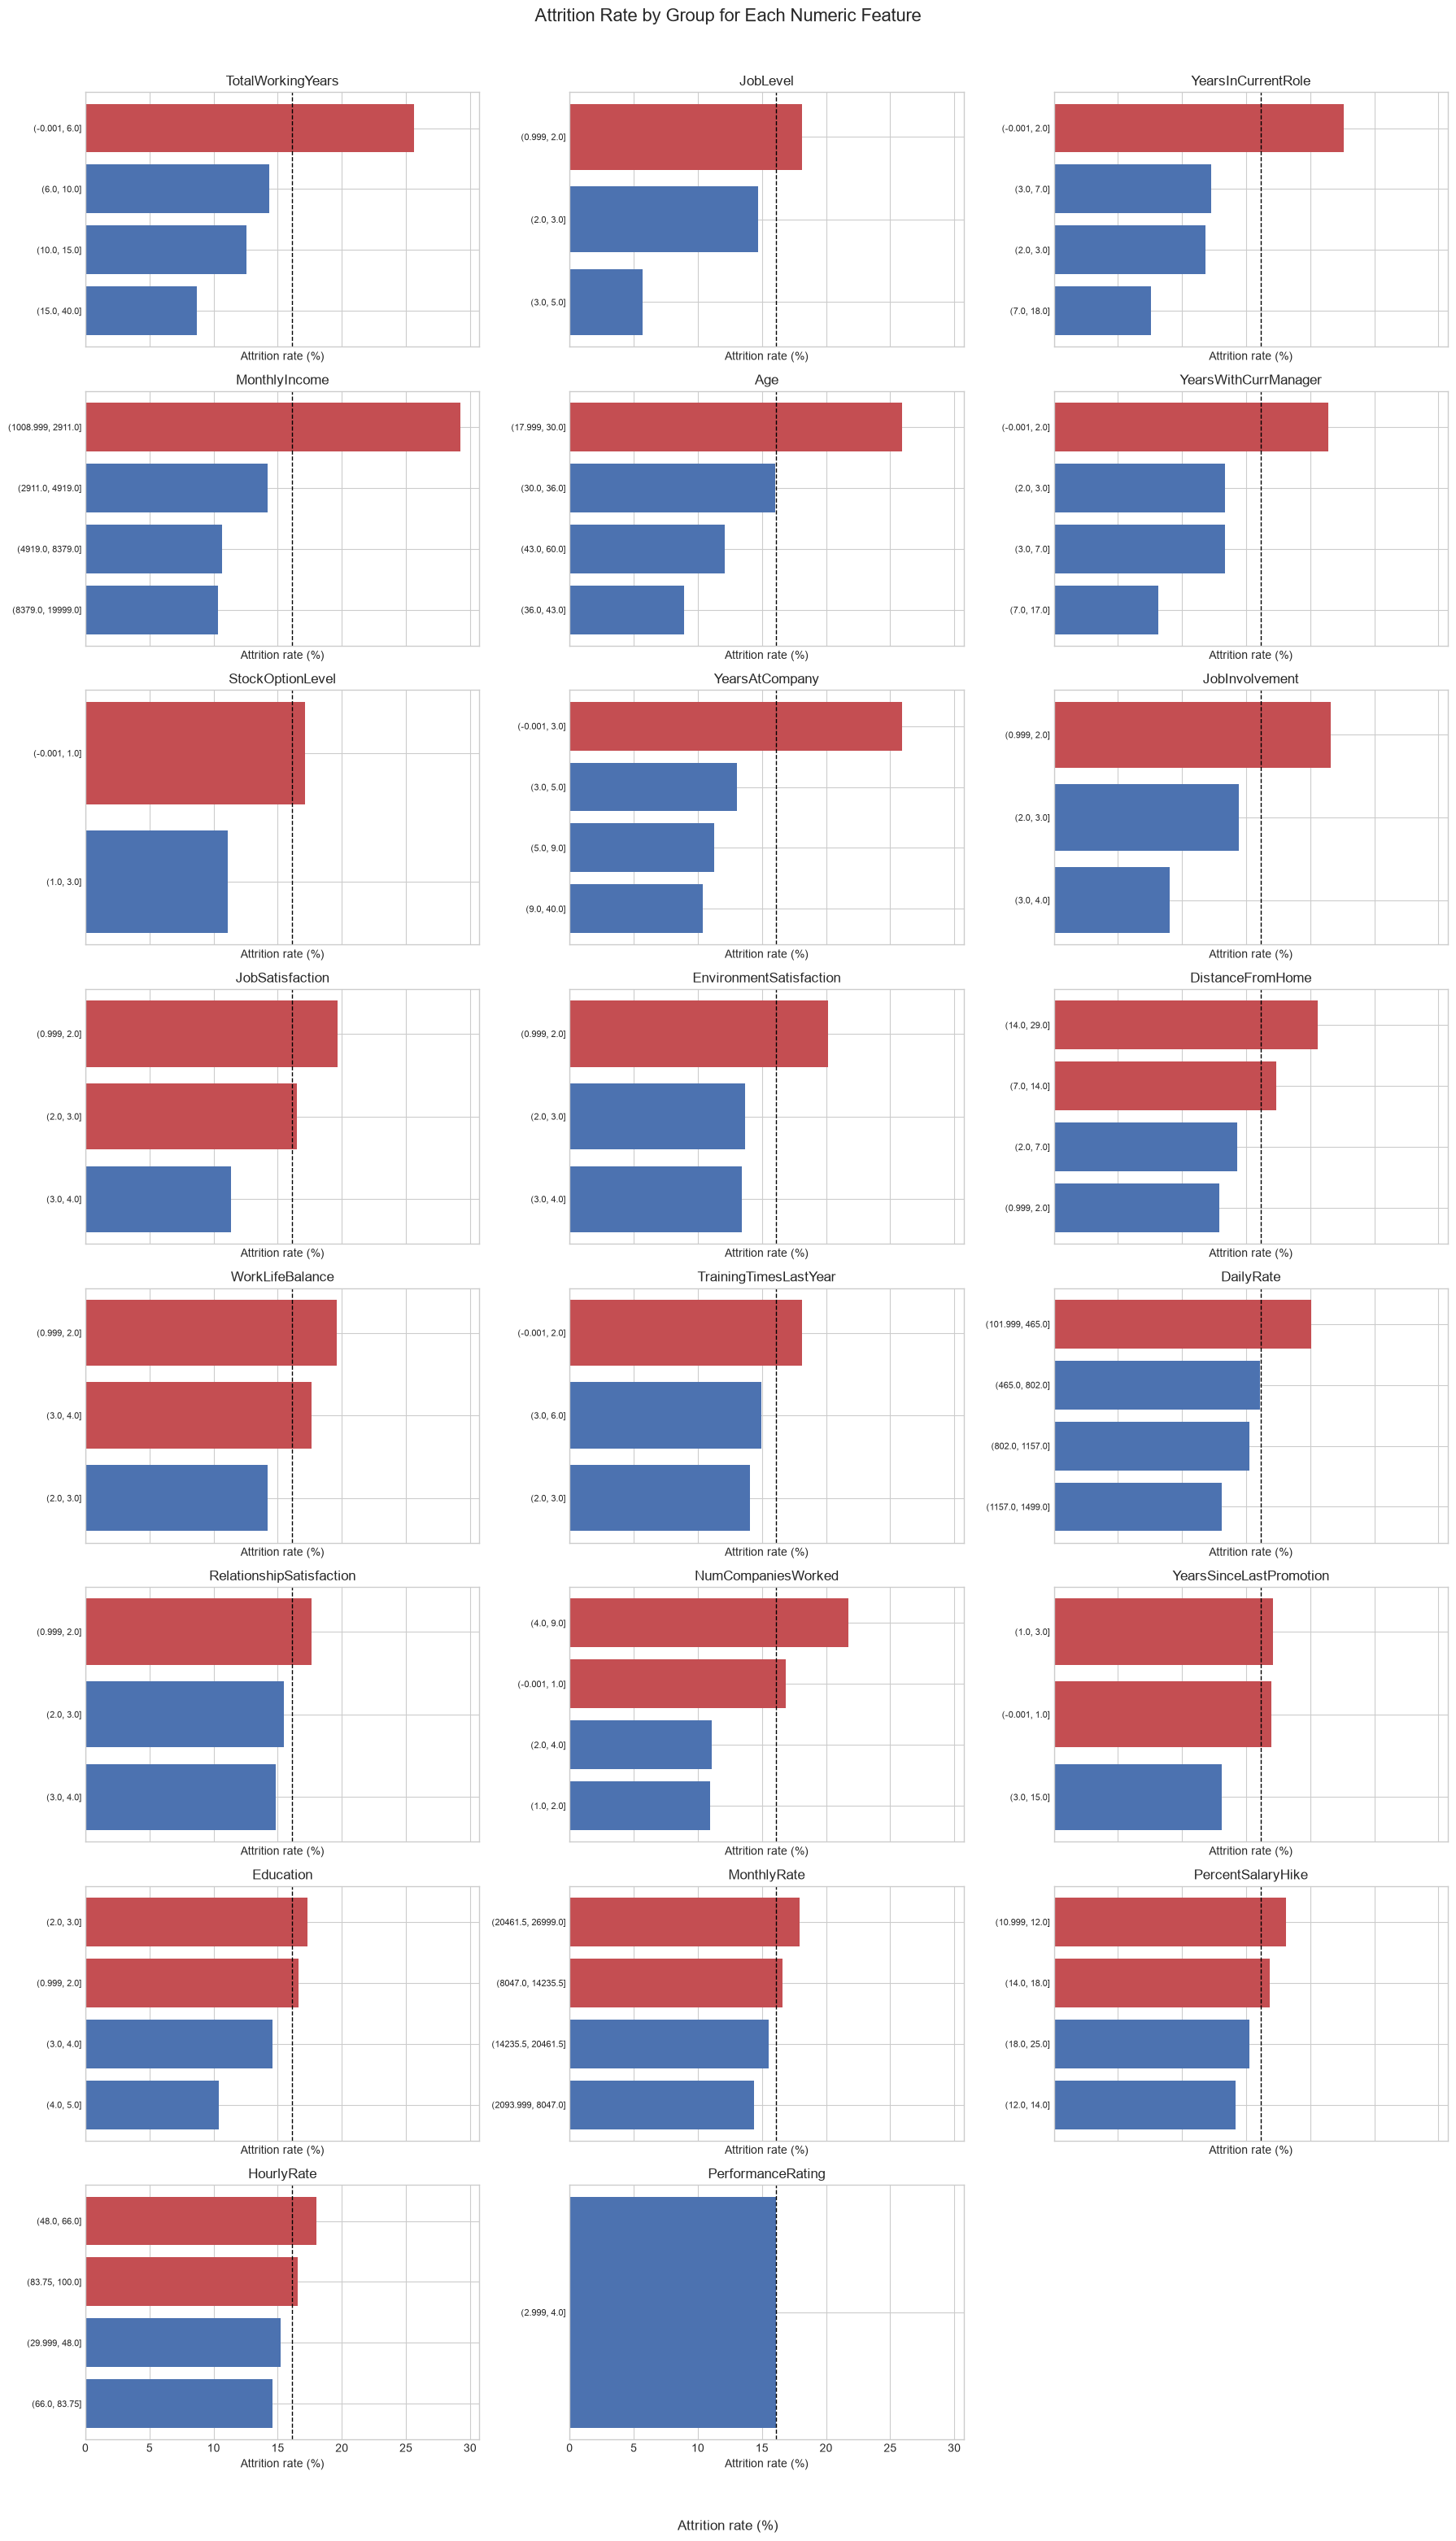

In [12]:
# Graph the attrition rate for every group in each feature-level table.
feature_count = len(attrition_correlations_by_group)
column_count = 3
row_count = (feature_count + column_count - 1) // column_count
fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(18, row_count * 4),
    sharex=True,
    squeeze=False
)
axes = axes.ravel()

for axis, (feature, correlation_df) in zip(axes, attrition_correlations_by_group.items()):
    plot_df = correlation_df.copy()
    plot_df["Group"] = plot_df["Group"].astype(str)
    plot_df = plot_df.sort_values("AttritionRate")
    colors = [
        "#c44e52" if value > baseline_rate else "#4c72b0"
        for value in plot_df["AttritionRate"]
    ]
    axis.barh(plot_df["Group"], plot_df["AttritionRate"] * 100, color=colors)
    axis.axvline(baseline_rate * 100, color="black", linestyle="--", linewidth=1)
    axis.set_title(feature)
    axis.set_xlabel("Attrition rate (%)")
    axis.tick_params(axis="y", labelsize=8)

for axis in axes[feature_count:]:
    axis.remove()

fig.suptitle("Attrition Rate by Group for Each Numeric Feature", fontsize=16)
fig.supxlabel("Attrition rate (%)")
fig.tight_layout(rect=(0, 0.02, 1, 0.97))
plt.show()

In [7]:
#Based on the above analysis, we can identify which features have the strongest correlation with
# attrition and which groups within those features have the highest or lowest attrition rates. 
# This information can be used to inform HR strategies and interventions aimed at reducing employee turnover.
# The features with the strongest correlation with attrition are likely to be the most important factors in predicting employee turnover, 
# and the groups within those features with the highest or lowest attrition rates can provide insights into which 
# employees are at the greatest risk of leaving the company.
# It seems the attrition rate is highest (above 20%) among employees with the following characteristics
# Less than 6 years worked, Less than 3 years at the company, less than 2 years in their current role, monthly income less than 2911, 
# age less than 30, less than 2 years with current managers, and those with low job involvement or environmental satisfaction or low daily rate of work, as well as those who worked plenty of other companies too.

